In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [5]:
TRAIN_DIR = "/home/kinkini/Desktop/smart-plant-health/data/train"

In [6]:
VAL_DIR = "/home/kinkini/Desktop/smart-plant-health/data/val"

In [32]:
classes = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight"
]

print("Classes:")
for class_name in classes:
    print(class_name)

Classes:
Tomato___healthy
Tomato___Early_blight
Tomato___Late_blight


In [33]:
image_path = os.path.join(
    TRAIN_DIR,
    '/home/kinkini/Desktop/smart-plant-health/data/train/Tomato___healthy'
)

In [34]:
image_files = os.listdir(image_path)

In [35]:
print("Number of images:", len(image_files))
print("First image:", image_files[0])

Number of images: 1273
First image: e5d58d21-5846-47aa-a0f7-e5f39c8f8567___RS_HL 0447.JPG


In [36]:
img = Image.open(
    os.path.join(image_path,image_files[0])
)

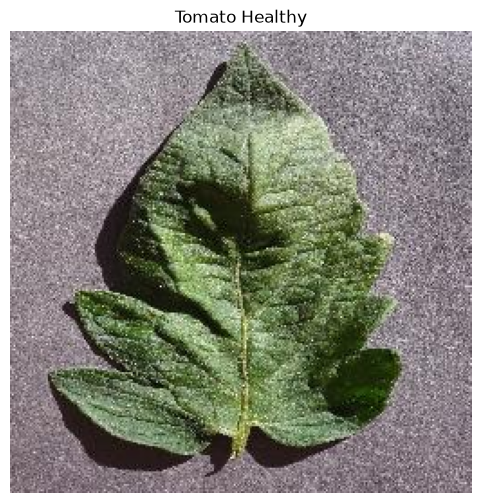

In [37]:
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Tomato Healthy')
plt.show()

In [38]:
import skimage

print(skimage.__version__)

0.26.0


In [39]:
from skimage.feature import hog
from skimage.color import rgb2gray

In [40]:
def extract_features(image_path):
    # Open image
    image = Image.open(image_path).convert("RGB")

    # Resize image
    image = image.resize((128, 128))

    # Convert to NumPy array
    image_array = np.array(image)

    # -------------------------
    # Color features
    # -------------------------
    mean_rgb = image_array.mean(axis=(0, 1))

    # -------------------------
    # HOG features
    # -------------------------
    gray_image = rgb2gray(image_array)

    hog_features = hog(
        gray_image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    # Combine color + HOG
    features = np.concatenate([
        mean_rgb,
        hog_features
    ])

    return features

In [41]:
test_image = os.path.join(
    TRAIN_DIR,
    "Tomato___healthy",
    image_files[0]
)

features = extract_features(test_image)

print("Feature vector shape:", features.shape)
print("Number of features:", len(features))

Feature vector shape: (8103,)
Number of features: 8103


In [42]:
def load_dataset(data_dir):
    X = []
    y = []

    for label, class_name in enumerate(classes):

        class_dir = os.path.join(data_dir, class_name)

        print(f"Processing: {class_name}")

        for filename in os.listdir(class_dir):

            image_path = os.path.join(class_dir, filename)

            try:
                features = extract_features(image_path)

                X.append(features)
                y.append(label)

            except Exception as e:
                print("Error:", image_path, e)

    return np.array(X), np.array(y)

In [43]:
X_train, y_train = load_dataset(TRAIN_DIR)

Processing: Tomato___healthy
Processing: Tomato___Early_blight
Processing: Tomato___Late_blight


In [44]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (3600, 8103)
y_train shape: (3600,)


In [45]:
X_val, y_val = load_dataset(VAL_DIR)

Processing: Tomato___healthy
Processing: Tomato___Early_blight
Processing: Tomato___Late_blight


In [46]:
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (900, 8103)
y_val shape: (900,)


In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [48]:
scaler = StandardScaler()

In [51]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Training data:", X_train_scaled.shape)
print("Validation data:", X_val_scaled.shape)

Training data: (3600, 8103)
Validation data: (900, 8103)


In [ ]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

In [ ]:
svm_model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = svm_model.predict(X_val_scaled)

In [ ]:
print("Predictions:", y_pred)
print("Actual:", y_val)